In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Customer Segmentation Using RFM Analysis

## Objective

Customer behavior is one of the most important drivers of marketplace growth.

This notebook uses RFM Analysis (Recency, Frequency, Monetary Value) to segment customers based on purchasing behavior.

Business Questions:

- Who are the most valuable customers?
- Which customers are most likely to purchase again?
- Which customers are at risk of churn?
- How should marketing efforts be prioritized?

# 1. Imports

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

#  2. Load Data

In [4]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")
master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


# 3. Create Customer-Level Dataset

In [6]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

analysis_date = (master["order_purchase_timestamp"].max()+ pd.Timedelta(days=1))

analysis_date

Timestamp('2018-09-04 09:06:57')

# 4. Calculate Recency
Days since last purchase

In [7]:
recency = (master.groupby("customer_unique_id")["order_purchase_timestamp"].max())

recency = (analysis_date-recency).dt.days

recency.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    116
0000b849f77a49e4a4ce2b2a4ca5be3f    119
0000f46a3911fa3c0805444483337064    542
0000f6ccb0745a6a4b88665a16c9f078    326
0004aac84e0df4da2b147fca70cf8255    293
Name: order_purchase_timestamp, dtype: int64

# 5. Calculate Frequency

In [9]:
frequency = (master.groupby("customer_unique_id")["order_id"].nunique())

frequency.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

#  6.Calculate Monetary Value

In [10]:
monetary = (master.groupby("customer_unique_id")["total_payment_value"].sum())

monetary.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19
0000f46a3911fa3c0805444483337064     86.22
0000f6ccb0745a6a4b88665a16c9f078     43.62
0004aac84e0df4da2b147fca70cf8255    196.89
Name: total_payment_value, dtype: float64

# 7. Build RFM Table

In [11]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
0000f46a3911fa3c0805444483337064,542,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
0004aac84e0df4da2b147fca70cf8255,293,1,196.89


# 8. RFM Distribution Analysis

In [28]:
rfm.shape

(95420, 8)

In [13]:
rfm.describe()

,Recency,Frequency,Monetary
count,95420.000000,95420.000000,95420.000000
mean,243.600377,1.034018,212.828911
std,153.160320,0.211234,641.760089
min,1.000000,1.000000,0.000000
25%,119.000000,1.000000,63.907500
50%,224.000000,1.000000,113.150000
75%,353.000000,1.000000,202.542500
max,729.000000,16.000000,109312.640000


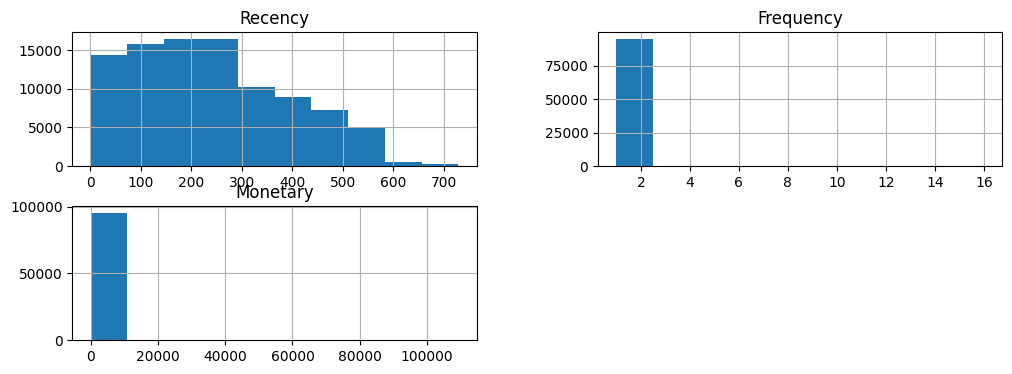

In [14]:
rfm.hist(figsize=(12,4))

plt.show()

# 9. Create RFM Scores

In [16]:
rfm["R_Score"] = pd.qcut(rfm["Recency"],5,labels=[5,4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),5,labels=[1,2,3,4,5])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],5,labels=[1,2,3,4,5])

In [18]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [19]:
rfm["RFM_Score"] = (rfm["R_Score"].astype(str)+
    rfm["F_Score"].astype(str)+
    rfm["M_Score"].astype(str))

In [21]:
def segment_customer(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"

    elif row["R_Score"] >= 4:
        return "Potential Loyalists"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = (rfm.apply(segment_customer,axis=1))

# 11. Segment Counts

In [23]:
rfm["Segment"].value_counts()

Segment
Lost Customers         22885
At Risk                22780
Loyal Customers        19195
Potential Loyalists    15283
Champions              15277
Name: count, dtype: int64

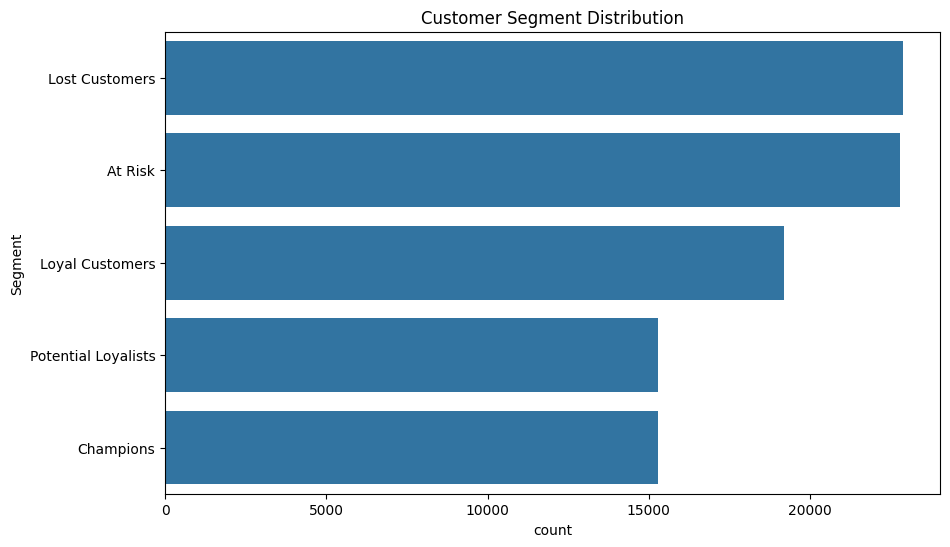

In [24]:
plt.figure(figsize=(10,6))

sns.countplot( y="Segment", data=rfm,
    order=rfm["Segment"].value_counts().index)

plt.title("Customer Segment Distribution")

plt.show()

# 12. Segment Performance

In [25]:
segment_summary = ( rfm.groupby("Segment")
    .agg({"Recency":"mean",
          "Frequency":"mean",
          "Monetary":"mean"}).round(2))

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,400.59,1.05,214.18
Champions,95.25,1.10,236.00
Lost Customers,343.42,1.00,207.34
Loyal Customers,173.99,1.04,205.54
Potential Loyalists,95.85,1.00,205.02


# 13. Revenue Contribution by Segment

In [26]:
segment_revenue = (rfm.groupby("Segment")["Monetary"].sum()
    .sort_values(ascending=False))

segment_revenue

Segment
At Risk                4878999.06
Lost Customers         4745047.09
Loyal Customers        3945291.31
Champions              3605433.71
Potential Loyalists    3133363.54
Name: Monetary, dtype: float64

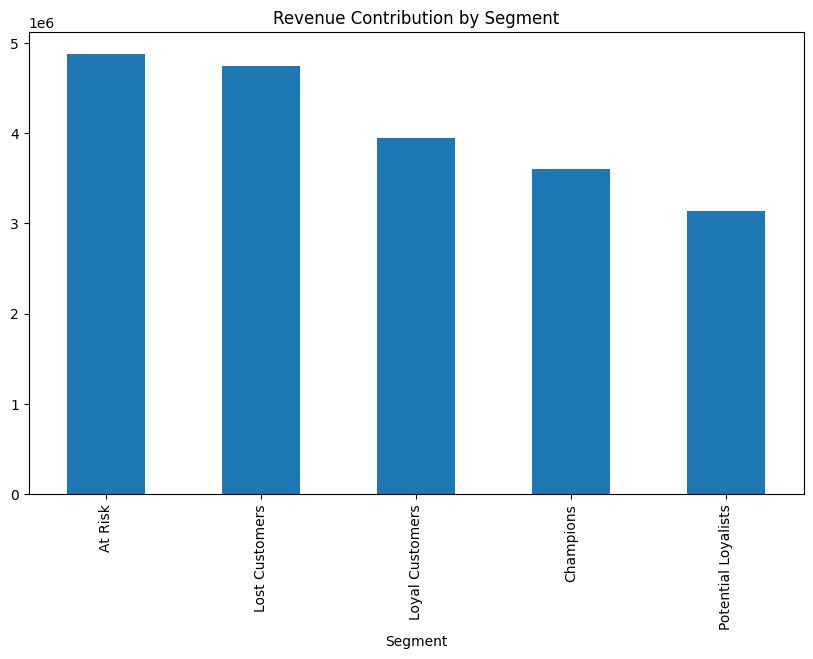

In [27]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Segment")

plt.show()

# Executive Customer Segmentation Summary

## Customer Base Overview

A total of 95,420 unique customers were analyzed using the RFM framework (Recency, Frequency, Monetary).

Key observations:

- Average Recency = 244 Days
- Average Frequency = 1.03 Orders
- Average Monetary Value = 212.83

The customer base is characterized by very low repeat purchase behavior, with approximately 97% of customers placing only one order.

This indicates that customer acquisition is strong but long-term retention remains a significant challenge.

---

## Segment Distribution

| Segment | Customers |
|----------|----------:|
| Lost Customers | 22,885 |
| At Risk | 22,780 |
| Loyal Customers | 19,195 |
| Potential Loyalists | 15,283 |
| Champions | 15,277 |

The largest customer groups are Lost Customers and At Risk Customers, suggesting a substantial portion of the customer base has become inactive.

---

## Revenue Contribution

The highest revenue contribution comes from:

1. At Risk Customers
2. Lost Customers
3. Loyal Customers

This indicates that a large amount of historical revenue originates from customers who are no longer actively engaged.

---

## Business Recommendations

### Champions

Reward and retain through loyalty programs, exclusive offers, and referral campaigns.

### Potential Loyalists

Encourage second purchases through personalized recommendations and promotional offers.

### Loyal Customers

Maintain engagement through retention programs and targeted communications.

### At Risk Customers

Prioritize reactivation campaigns because this segment represents the largest revenue opportunity.

### Lost Customers

Implement large-scale re-engagement initiatives while maintaining lower marketing investment priority.

---

## Strategic Conclusion

The analysis reveals that customer retention is the primary growth opportunity for the marketplace.

While customer acquisition appears successful, repeat purchasing behavior remains limited. Future business initiatives should focus on increasing customer lifetime value and reducing customer churn, particularly among high-value customers currently classified as At Risk.

# 15. Customer Lifetime Value Analysis

## Objective

While RFM segmentation identifies customer behavior patterns, it does not reveal how revenue is distributed across the customer base.

This section analyzes customer lifetime value (CLV) to answer:

- How concentrated is revenue?
- Do a small number of customers generate most revenue?
- Who are the highest-value customers?
- Does the business follow the Pareto Principle (80/20 Rule)?

Understanding revenue concentration helps prioritize retention and customer acquisition strategies.

##  15.1 — Customer Lifetime Value Distribution


In [29]:
customer_clv = (master.groupby("customer_unique_id")
    ["total_payment_value"].sum().reset_index())

customer_clv.rename(columns={"total_payment_value":"clv"},inplace=True)

customer_clv.head()

,customer_unique_id,clv
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [30]:
customer_clv["clv"].describe()

count     95420.000000
mean        212.828911
std         641.760089
min           0.000000
25%          63.907500
50%         113.150000
75%         202.542500
max      109312.640000
Name: clv, dtype: float64

### Interpretation

Customer Lifetime Value (CLV) represents the total revenue generated by each customer across all purchases.

The distribution helps identify:

- Typical customer value
- High-value outliers
- Revenue inequality
- Business dependence on top customers

##  15.2 — CLV Distribution

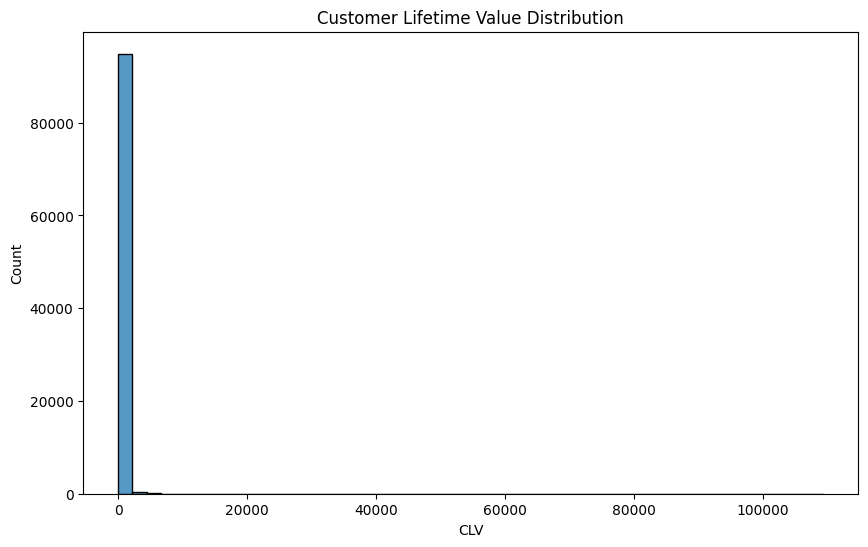

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(customer_clv["clv"],bins=50)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("CLV")

plt.show()

# Revenue Concentration Analysis

This analysis measures how much revenue is generated by the highest-value customers.

If a small percentage of customers generate most revenue, retention efforts should focus heavily on these customers.

In [32]:
top_1_pct = int(len(customer_clv) * 0.01)

top_1_revenue_share = (customer_clv["clv"] .sort_values(ascending=False)
    .head(top_1_pct).sum() /customer_clv["clv"].sum())

print(f"Top 1% Revenue Share: "f"{top_1_revenue_share:.2%}")

Top 1% Revenue Share: 17.05%


In [33]:
 top_5_pct = int(len(customer_clv) * 0.05)

top_5_revenue_share = (customer_clv["clv"].sort_values(ascending=False).head(top_5_pct).sum()
    /customer_clv["clv"].sum()
)

print(f"Top 5% Revenue Share: "f"{top_5_revenue_share:.2%}")

Top 5% Revenue Share: 35.38%


In [34]:
top_10_pct = int(len(customer_clv) * 0.10)

top_10_revenue_share = ( customer_clv["clv"] .sort_values(ascending=False) .head(top_10_pct).sum()
    /customer_clv["clv"].sum())

print( f"Top 10% Revenue Share: " f"{top_10_revenue_share:.2%}")

Top 10% Revenue Share: 47.40%


## 15.4 — Pareto Analysis

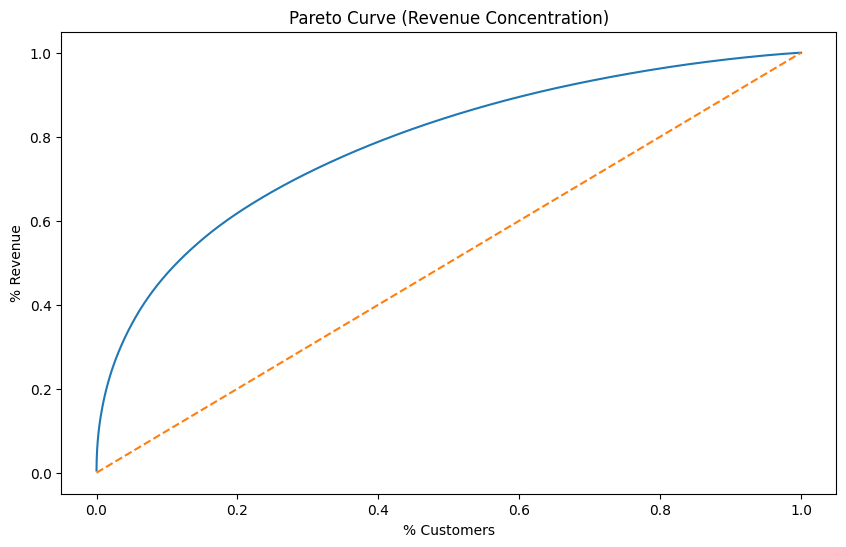

In [36]:
clv_sorted = (customer_clv.sort_values( "clv", ascending=False).reset_index(drop=True))

clv_sorted["cum_revenue_pct"] = (clv_sorted["clv"].cumsum()
    /clv_sorted["clv"].sum())

clv_sorted["cum_customer_pct"] = (np.arange(1,len(clv_sorted)+1)
    /len(clv_sorted))

plt.figure(figsize=(10,6))

plt.plot(clv_sorted["cum_customer_pct"],clv_sorted["cum_revenue_pct"])

plt.plot([0,1],[0,1],linestyle="--")

plt.title("Pareto Curve (Revenue Concentration)")

plt.xlabel( "% Customers")

plt.ylabel("% Revenue")

plt.show()

## 15.5 — 80/20 Rule Check

In [37]:
customers_for_80pct = (clv_sorted[ clv_sorted["cum_revenue_pct"] <= 0.80].shape[0])

pct_customers_for_80 = (customers_for_80pct/len(clv_sorted))

print(f"Customers generating 80% revenue: "f"{pct_customers_for_80:.2%}")

Customers generating 80% revenue: 41.85%


## 15.6 — Top Customers

In [38]:
top_customers = (customer_clv.sort_values("clv",ascending=False).head(10))

top_customers

,customer_unique_id,clv
3799,0a0a92112bd4c708ca5fde585afaa872,109312.64
39443,698e1cf81d01a3d389d96145f7fa6df8,45256.00
73155,c402f431464c72e27330a67f7b94d4fb,44048.00
23947,4007669dec559734d6f53e029e360987,36489.24
89365,ef8d54b3797ea4db1d63f0ced6a906e9,30186.00
44139,763c8b1c9c68a0229c42c9fc6f662b93,29099.52
74752,c8460e4251689ba205045f3ea17884a1,27935.46
87642,eae0a83d752b1dd32697e0e7b4221656,25051.89
22910,3d47f4368ccc8e1bb4c4a12dbda7111b,22346.60
64943,adfa1cab2b2c8706db21bb13c0a1beb1,19457.04


# Executive Customer Lifetime Value (CLV) Summary

## Objective

Customer Lifetime Value (CLV) analysis was performed to understand revenue concentration across the customer base and identify the importance of high-value customers.

The analysis evaluates whether a small percentage of customers generate a disproportionate share of marketplace revenue.

---

## Customer Value Distribution

A total of 95,420 customers were analyzed.

### Key Statistics

| Metric | Value |
|----------|----------:|
| Average CLV | 212.83 |
| Median CLV | 113.15 |
| 75th Percentile | 202.54 |
| Maximum CLV | 109,312.64 |

### Interpretation

The average customer generates approximately 213 in lifetime revenue, while the median customer generates only 113.

This large gap between mean and median indicates a right-skewed distribution where a relatively small number of high-value customers generate substantially more revenue than typical customers.

The highest-value customer generated over 109,000 in revenue, demonstrating the presence of extreme spending outliers.

---

## Revenue Concentration Analysis

### Revenue Share by Top Customers

| Customer Group | Revenue Share |
|----------|----------:|
| Top 1% Customers | 17.05% |
| Top 5% Customers | 35.38% |
| Top 10% Customers | 47.40% |

### Interpretation

Revenue is concentrated among higher-value customers, but the concentration is less extreme than many subscription or luxury-commerce businesses.

The top 10% of customers generate approximately 47% of total revenue, indicating that revenue is distributed across a relatively broad customer base rather than being dominated by a very small number of buyers.

---

## Pareto Principle Evaluation

The classic Pareto Principle suggests:

- 20% of customers generate 80% of revenue.

Observed result:

- 41.85% of customers generate 80% of revenue.

### Conclusion

The marketplace does not exhibit a traditional 80/20 pattern.

Instead, revenue is more evenly distributed across customers.

This reduces dependence on a small group of customers and lowers concentration risk.

---

## Top Customer Analysis

The highest-value customer generated:

- 109,312.64 in lifetime revenue.

The top ten customers generated exceptionally large revenues compared to the average customer, indicating the existence of a small but valuable VIP customer segment.

These customers should be prioritized for retention and relationship management programs.

---

## Business Implications

### Positive Findings

- Revenue is diversified across a large customer base.
- The business is not excessively dependent on a handful of customers.
- Revenue concentration risk is relatively low.

### Areas for Improvement

- Average customer lifetime value remains relatively modest.
- Customer frequency remains extremely low.
- Increasing repeat purchases would likely have a larger impact on revenue than acquiring additional low-frequency customers.

---

## Strategic Recommendations

### High-Value Customer Strategy

Identify and retain the top 1–5% of customers through:

- VIP programs
- Personalized offers
- Premium support
- Exclusive promotions

### Retention Strategy

Focus on increasing customer frequency because:

- Nearly 97% of customers purchase only once.
- Small improvements in repeat purchasing behavior could significantly increase lifetime value.

### Growth Strategy

Rather than concentrating solely on customer acquisition, future growth initiatives should emphasize:

- Retention
- Repeat purchases
- Customer lifetime value expansion

---

## Executive Conclusion

Customer lifetime value analysis reveals that revenue is broadly distributed across the marketplace rather than concentrated among a small elite customer group.

The primary business opportunity is not reducing concentration risk, but increasing customer retention and purchase frequency.

Future growth is likely to be driven more effectively by improving customer lifetime value than by acquiring additional one-time purchasers.